In [21]:
import pandas as pd
df = pd.read_pickle('/Users/yang./Desktop/测试数据-2020至今.pk')
df = df.dropna()
dp = df['close'].unstack()
dp

code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-01-02,1841.6882,4832.2920,90.7460,29.1003,191.3002,79.1077,82.8549,59.0007,36.7412,34.2681,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,1875.5308,4756.6019,90.8273,29.1929,194.1343,78.7764,83.7482,56.6974,36.7412,34.1960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,1863.5221,4676.4595,88.3890,29.1929,193.4257,78.5278,83.3015,62.3672,36.9567,33.8357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,1872.2557,4713.5625,89.8114,29.6563,194.4885,78.7764,84.6415,63.4302,38.1419,34.4122,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,1818.7627,4701.6895,88.5109,29.1929,190.9459,77.8652,83.0782,62.9873,37.8187,33.4753,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,999.0840,1231.9517,35.4775,7.6921,249.1678,60.3041,63.8636,81.3312,36.6335,38.8147,...,59.5828,25.4327,84.18,33.5764,18.7988,11.7315,32.71,44.7558,27.8200,513.4781
2025-07-28,1007.9827,1233.7687,35.8839,7.6921,254.3339,60.3041,63.4155,83.7549,37.2799,38.7265,...,59.7254,25.3779,83.14,35.5440,18.8832,11.6704,33.81,44.6235,27.3663,516.2475
2025-07-29,998.2750,1237.4028,35.7620,7.6921,251.9495,59.5586,63.4155,82.6777,37.2799,39.0353,...,60.2673,25.3011,88.46,34.6663,19.0309,11.5889,34.90,45.4177,27.1747,526.7832


In [94]:
future_df = dp.shift(-20) / dp - 1
future_df

code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-01-02,-0.133373,-0.155405,-0.034035,-0.095542,-0.162963,-0.207330,-0.177898,-0.010510,0.000000,-0.188225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.155995,-0.105460,-0.020134,-0.088888,-0.162409,-0.124080,-0.165334,0.132812,0.005865,-0.173868,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,-0.133568,-0.077118,-0.017472,-0.095235,-0.146520,-0.147679,-0.163538,0.015624,0.000000,-0.149097,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,-0.138776,-0.084383,-0.021268,-0.103125,-0.149363,-0.145111,-0.171505,0.012570,-0.031073,-0.162303,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,-0.120648,-0.054609,-0.022038,-0.107934,-0.135436,-0.136171,-0.163979,-0.004220,-0.031339,-0.138858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
momentum_20 = dp.pct_change(20)
lower = momentum_20.quantile(0.05)
upper = momentum_20.quantile(0.95)
momentum_20 = momentum_20.clip(lower,upper,axis=1)
momentum_20 = (momentum_20 - momentum_20.mean(axis=1).values.reshape(-1,1)) / momentum_20.std(axis=1).values.reshape(-1,1)
momentum_20

/var/folders/zt/lhp1r6t56dg6llm53jc0td680000gn/T/ipykernel_1179/3653992149.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  momentum_20 = dp.pct_change(20)


code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,-0.602322,-0.022219,-0.666304,-0.748664,-1.495904,-1.353881,-0.448976,-0.397000,0.883467,-0.240998,...,0.060670,-0.317692,0.603931,-0.103263,-0.276487,-0.242435,0.952290,1.753276,0.730649,-0.301235
2025-07-28,-0.263325,0.036658,-0.672907,-0.646126,-0.737966,-1.159858,-0.476260,-0.045764,1.125036,-0.183471,...,0.020182,-0.372159,0.086193,0.640589,-0.291705,-0.206576,1.670534,1.844192,0.373180,-0.941161
2025-07-29,-0.560831,0.229508,-0.864213,-0.597978,-0.687360,-1.142634,-0.392533,-0.497881,1.331537,-0.028873,...,0.092838,-0.364116,1.191330,0.478954,-0.143696,-0.267556,1.655252,1.803145,0.243937,-0.391980


In [35]:
momentum_20_long = momentum_20.stack()
df['momentum_20_long'] = momentum_20_long
df

close      free_mkt   industry  status  \
trade_dt   code                                                    
2020-01-02 000001.SZ  1841.6882  1.451008e+11  801780.SI       0   
           000002.SZ  4832.2920  1.976077e+11  801180.SI       0   
           000004.SZ    90.7460  1.190862e+09  801150.SI       0   
           000005.SZ    29.1003  2.592888e+09  801160.SI       0   
           000006.SZ   191.3002  4.656473e+09  801180.SI       0   
...                         ...           ...        ...     ...   
2025-07-31 688799.SH    84.7347  4.446411e+09  801150.SI       0   
           688800.SH    99.1180  7.097760e+09  801080.SI       0   
           688819.SH    30.1375  3.717844e+09  801730.SI       0   
           688981.SH    89.5000  1.511312e+11  801080.SI       0   
           689009.SH    62.0949  3.241894e+10  801880.SI       0   

                      momentum_20_long  momentum_20  
trade_dt   code                                      
2020-01-02 000001.SZ               NaN          NaN  
           000002.SZ               NaN          NaN  
           000004.SZ               NaN          NaN  
           000005.SZ               NaN          NaN  
           000006.SZ               NaN          NaN  
...                                ...          ...  
2025-07-31 688799.SH          1.612965     1.612965  
           688800.SH          1.740528     1.740528  
           688819.SH         -0.260328    -0.260328  
           688981.SH          0.029691     0.029691  
           689009.SH         -0.613476    -0.613476  

[5974269 rows x 6 columns]

In [142]:
import numpy as np
import statsmodels.api as sm
def neutralize(df):
    neutralize_results = []
    corr_results = []
    for date,group in df.groupby('trade_dt'):
        dp = group.copy()

        dp = dp[dp['free_mkt'] > 0]
        dp['log_free_mkt'] = np.log(dp['free_mkt'])
        lower = dp['log_free_mkt'].quantile(0.05)
        upper = dp['log_free_mkt'].quantile(0.95)
        dp['log_free_mkt'] = dp['log_free_mkt'].clip(lower,upper)
        dp['log_free_mkt'] = (dp['log_free_mkt'] - dp['log_free_mkt'].mean()) / dp['log_free_mkt'].std()
        industry_dummies = pd.get_dummies(dp['industry'],dtype=float)

        #第一步：市值对行业中性化
        x_mkt = industry_dummies
        x_mkt = sm.add_constant(x_mkt)
        y_mkt = dp['log_free_mkt']
        #处理缺失值
        valid_mkt = y_mkt.notna() & x_mkt.notna().all(axis=1)
        y_mkt = y_mkt[valid_mkt]
        x_mkt = x_mkt[valid_mkt]
        if len(y_mkt) < 10:
            continue
        #回归
        model_mkt = sm.OLS(y_mkt,x_mkt).fit()
        #残差=对行业中性化后的市值
        dp.loc[valid_mkt,'mkt_neutral'] = model_mkt.resid

        #第二步：因子对市值、行业中性化
        y_factor = dp['momentum_20_long']
        x_factor = pd.concat([dp['mkt_neutral'],industry_dummies],axis=1)
        x_factor = sm.add_constant(x_factor)

        valid_factor = y_factor.notna() & x_factor.notna().all(axis=1)
        y_factor = y_factor[valid_factor]
        x_factor = x_factor[valid_factor]
        if len(y_factor) < 10:
            continue
        model_factor = sm.OLS(y_factor,x_factor).fit()

        dp.loc[valid_factor,'neutral_momentum_20'] = model_factor.resid

        #因子中性化前后因子与市值相关性对比
        corr_before_df = dp[['momentum_20_long', 'log_free_mkt']].dropna()
        corr_after_df = dp[['neutral_momentum_20', 'log_free_mkt']].dropna()

        corr_before = np.nan
        corr_after = np.nan

        if len(corr_before_df) >= 2:
            corr_before = corr_before_df['momentum_20_long'].corr(corr_before_df['log_free_mkt'])

        if len(corr_after_df) >= 2:
            corr_after = corr_after_df['neutral_momentum_20'].corr(corr_after_df['log_free_mkt'])

        corr_results.append({
            'date': date,
            'corr_before': corr_before,
            'corr_after': corr_after
        })
        corr_results_df = pd.DataFrame(corr_results).set_index('date')
        
        neutralize_results.append(dp[['mkt_neutral','neutral_momentum_20']])
    neutralize_results_df = pd.concat(neutralize_results)
    return neutralize_results_df,corr_results_df

In [146]:
momentum_20_neutral,corr_compare = neutralize(df)
momentum_20_neutral

mkt_neutral  neutral_momentum_20
trade_dt   code                                       
2020-02-07 000001.SZ     0.528828            -0.558042
           000002.SZ     2.004958            -0.803910
           000004.SZ    -1.199473            -0.705008
           000005.SZ    -0.036592            -0.139614
           000006.SZ     0.276317            -0.284128
...                           ...                  ...
2025-07-31 688799.SH    -0.023388             0.915760
           688800.SH     0.353419             1.675107
           688819.SH    -0.092463            -0.105583
           688981.SH     1.815182            -0.232182
           689009.SH     2.148954            -0.743870

[5898564 rows x 2 columns]

In [147]:
corr_compare

,corr_before,corr_after
date,,
2020-02-07,0.285745,-1.291298e-15
2020-02-10,0.274409,-8.077518e-16
2020-02-11,0.287764,-9.187303e-16
2020-02-12,0.295817,-6.853072e-16
2020-02-13,0.304918,-6.315604e-16
...,...,...
2025-07-25,0.106601,3.189572e-16
2025-07-28,0.098655,3.433174e-17
2025-07-29,0.141577,3.769696e-16


In [150]:
print(f"corr_mean_before:{corr_compare['corr_before'].mean():.20f},corr_mean_after:{corr_compare['corr_after'].mean():.20f}")

corr_mean_before:0.05592217155713487264,corr_mean_after:0.00000000000000006095


In [95]:
future_long = future_df.stack()
momentum_20_neutral['future_long'] = future_long
momentum_20_neutral

mkt_neutral  neutral_momentum_20  future_long
trade_dt   code                                                    
2020-02-07 000001.SZ     0.528828            -0.558042     0.028044
           000002.SZ     2.004958            -0.803910     0.132000
           000004.SZ    -1.199473            -0.705008     0.942513
           000005.SZ    -0.036592            -0.139614     0.073944
           000006.SZ     0.276317            -0.284128     0.095133
...                           ...                  ...          ...
2025-07-31 688799.SH    -0.023388             0.915760          NaN
           688800.SH     0.353419             1.675107          NaN
           688819.SH    -0.092463            -0.105583          NaN
           688981.SH     1.815182            -0.232182          NaN
           689009.SH     2.148954            -0.743870          NaN

[5898564 rows x 3 columns]

In [96]:
future_df = momentum_20_neutral['future_long'].unstack()
future_df

code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-02-07,0.028044,0.132000,0.942513,0.073944,0.095133,0.216645,0.137705,0.215479,0.082112,0.073837,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-10,-0.003448,0.065574,0.821461,0.055749,0.045751,0.132053,0.130991,0.051036,0.037901,0.025511,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-11,-0.002028,0.059147,0.910155,0.077190,0.040772,0.126238,0.157051,0.076924,0.049563,0.007509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-12,-0.005416,0.044704,0.834952,0.076656,0.044968,0.093481,0.149682,0.015173,0.049563,0.008749,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-13,0.002048,0.000000,0.803285,0.056939,0.023605,0.046799,0.122187,-0.014124,0.047058,0.002498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
momentum_20 = momentum_20_neutral['neutral_momentum_20'].unstack()
momentum_20 = (momentum_20 - momentum_20.mean(axis=1).values.reshape(-1,1)) / momentum_20.std(axis=1).values.reshape(-1,1)
momentum_20

code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-02-07,-0.651432,-0.938446,-0.822992,-0.162979,-0.331677,-0.511751,-0.866804,-0.252201,0.945794,0.036418,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-10,-0.652964,-0.590278,-0.573625,-0.140655,-0.418875,-0.241917,-0.975087,0.917248,0.907154,-0.047721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-11,-0.697803,-0.365997,-0.527862,-0.079081,-0.456744,-0.385973,-0.917091,-0.026187,0.894855,-0.060854,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-12,-0.695591,-0.437576,-0.468537,-0.140193,-0.430289,-0.317555,-0.950976,-0.029886,0.625205,-0.030396,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-13,-0.599756,-0.291311,-0.458348,-0.241877,-0.438769,-0.254405,-0.983328,-0.185998,0.594561,-0.026871,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,0.133833,-0.346673,-0.446375,-0.565469,-1.678683,-1.001373,-0.673224,-0.740775,0.955630,-0.205015,...,0.346446,-0.254694,0.646101,0.077417,-0.335483,-0.190202,0.293121,1.289426,0.846769,-0.726974
2025-07-28,0.249616,-0.321647,-0.430967,-0.491582,-0.945454,-0.890819,-0.666956,-0.330462,1.258428,-0.230105,...,0.205827,-0.333348,0.041721,0.877833,-0.340185,-0.195804,1.004097,1.322782,0.446629,-1.335157
2025-07-29,0.245225,-0.306221,-0.749546,-0.257685,-1.002329,-0.786379,-0.609597,-0.825495,1.454232,-0.127046,...,0.208129,-0.166561,1.023228,0.568242,-0.163768,-0.061843,1.043783,1.392110,0.471033,-0.866479


In [97]:
def ic(factor_df,future_df,start_idx):
    ic_results = []
    for i in range(start_idx,len(factor_df)-20):
        factor = factor_df.iloc[i]
        future = future_df.iloc[i]
        dp = pd.DataFrame({
            'factor':factor,
            'future':future
        }).dropna()
        ic = dp['factor'].corr(dp['future'],method = 'spearman')
        ic_results.append({
            'date':factor_df.index[i],
            'ic':ic
        })
    ic_results_df = pd.DataFrame(ic_results)
    ic_results_df['date'] = pd.to_datetime(ic_results_df['date'])
    ic_results_df = ic_results_df.set_index('date')
    ic_results_df['cum_ic'] = ic_results_df['ic'].cumsum()
    return ic_results_df

In [98]:
momentum_20_ic = ic(momentum_20,future_df,30)
momentum_20_ic

,ic,cum_ic
date,,
2020-03-20,-0.090661,-0.090661
2020-03-23,-0.086213,-0.176874
2020-03-24,-0.063727,-0.240601
2020-03-25,-0.026068,-0.266669
2020-03-26,-0.021102,-0.287771
...,...,...
2025-06-27,-0.063463,-65.247537
2025-06-30,-0.019148,-65.266685
2025-07-01,-0.019456,-65.286140


In [99]:
print((momentum_20_ic['ic'] > 0).mean())
print(f"rank ic mean:{momentum_20_ic['ic'].mean()}")
print(f"rank ic std:{momentum_20_ic['ic'].std()}")
print(f"rank icir:{momentum_20_ic['ic'].mean() / momentum_20_ic['ic'].std()}")

0.30679156908665106
rank ic mean:-0.05102069833475858
rank ic std:0.09380682617101337
rank icir:-0.543891104915392


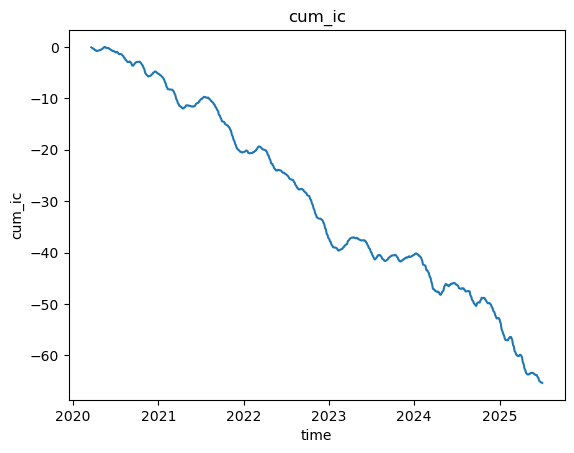

In [100]:
import matplotlib.pyplot as plt
plt.plot(momentum_20_ic['cum_ic'])
plt.xlabel('time')
plt.ylabel('cum_ic')
plt.title('cum_ic')
plt.show()

In [105]:
def group(factor_df,future_df,start_idx,n_groups):
    group_results = []
    test_date = momentum_20.index[start_idx:len(factor_df)-20:20]
    for date in test_date:
        factor = factor_df.loc[date]
        future = future_df.loc[date]
        dp = pd.DataFrame({
            'factor':factor,
            'future':future
        }).dropna()
        dp['rank'] = dp['factor'].rank()
        dp['quantile'] = pd.qcut(dp['rank'],n_groups,labels=False)
        group_return = dp.groupby('quantile')['future'].mean()
        group_return['date'] = date
        group_results.append(group_return)
    group_results_df = pd.DataFrame(group_results)
    group_results_df['date'] = pd.to_datetime(group_results_df['date'])
    group_results_df = group_results_df.set_index('date')
    group_results_df['long_short'] = group_results_df[0] - group_results_df[n_groups - 1]
    return group_results_df

In [106]:
group_momentum_20 = group(momentum_20,future_df,30,10)
group_momentum_20

quantile,0,1,2,3,4,5,6,7,8,9,long_short
date,,,,,,,,,,,
2020-03-20,0.018396,0.021864,0.020415,0.025592,0.029368,0.015001,0.018135,0.013335,0.000697,0.000427,0.017969
2020-04-20,-0.025005,-0.018184,-0.017580,-0.007497,-0.009278,0.000113,-0.005609,0.007297,-0.006277,-0.021883,-0.003122
2020-05-21,0.076471,0.064449,0.055635,0.055714,0.054105,0.053023,0.063948,0.060393,0.062890,0.071390,0.005081
2020-06-18,0.110819,0.123722,0.135320,0.138329,0.139159,0.124100,0.137291,0.137043,0.115737,0.125924,-0.015105
2020-07-20,0.031974,0.050938,0.056279,0.042639,0.045693,0.045166,0.050963,0.048177,0.057917,0.064759,-0.032785
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-06,-0.028781,0.007881,0.006828,-0.003478,-0.006647,-0.007422,-0.014905,-0.039351,-0.056400,-0.085066,0.056285
2025-04-03,0.005534,-0.001129,0.010151,-0.006229,-0.001167,-0.003264,-0.001954,-0.004870,0.002123,0.015084,-0.009550
2025-05-07,0.042500,0.036117,0.037683,0.027516,0.036054,0.037445,0.032063,0.038800,0.057568,0.044931,-0.002431


In [123]:
the_group_results = []
for columns in group_momentum_20.columns:
    cumprod = (1 + group_momentum_20[columns]).cumprod()
    cummax = cumprod.cummax()
    annual_return = cumprod.iloc[-1] ** (252 / (len(group_momentum_20[columns]) * 20)) - 1
    annual_volatility = group_momentum_20[columns].std() * (252/20) ** 0.5
    sharpe = group_momentum_20[columns].mean() / group_momentum_20[columns].std() * (252/20) ** 0.5
    drawdown = (cumprod - cummax) / cummax
    max_drawdown = drawdown.min()
    the_group_results.append({
        'group':columns,
        'annual_return':annual_return,
        'volatility':annual_volatility,
        'sharpe':sharpe,
        'max_drawdown':max_drawdown
    })
the_group_results_df = pd.DataFrame(the_group_results)
the_group_results_df = the_group_results_df.set_index('group')
the_group_results_df

,annual_return,volatility,sharpe,max_drawdown
group,,,,
0,0.066984,0.248016,0.380668,-0.425289
1,0.147641,0.228973,0.713650,-0.268696
2,0.168152,0.218804,0.818159,-0.232477
3,0.176734,0.211050,0.876062,-0.243212
4,0.171236,0.203846,0.876508,-0.223227
5,0.151724,0.201615,0.800321,-0.197406
6,0.148381,0.200252,0.790012,-0.217447
7,0.130682,0.199909,0.713373,-0.220835
8,0.055843,0.202472,0.366507,-0.342143


In [107]:
cum_group_momentum_20 = (1 + group_momentum_20).cumprod()
cum_group_momentum_20

quantile,0,1,2,3,4,5,6,7,8,9,long_short
date,,,,,,,,,,,
2020-03-20,1.018396,1.021864,1.020415,1.025592,1.029368,1.015001,1.018135,1.013335,1.000697,1.000427,1.017969
2020-04-20,0.992931,1.003282,1.002476,1.017903,1.019818,1.015116,1.012425,1.020729,0.994416,0.978535,1.014790
2020-05-21,1.068861,1.067943,1.058249,1.074614,1.074995,1.068940,1.077167,1.082373,1.056954,1.048392,1.019947
2020-06-18,1.187311,1.200071,1.201452,1.223264,1.224591,1.201595,1.225052,1.230705,1.179283,1.180410,1.004540
2020-07-20,1.225274,1.261201,1.269069,1.275422,1.280546,1.255867,1.287485,1.289996,1.247583,1.256852,0.971606
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-06,1.254130,1.828241,1.952543,2.088843,2.005191,1.802085,1.804581,1.656023,1.141161,0.682331,1.774051
2025-04-03,1.261071,1.826177,1.972362,2.075831,2.002852,1.796204,1.801056,1.647959,1.143584,0.692623,1.757109
2025-05-07,1.314666,1.892132,2.046688,2.132949,2.075063,1.863463,1.858804,1.711899,1.209417,0.723743,1.752838


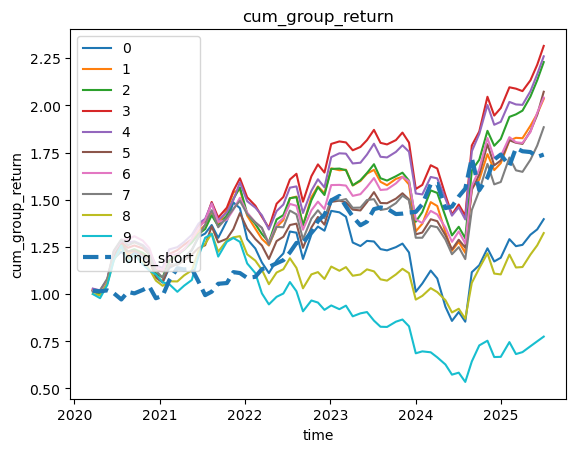

In [116]:
for columns in cum_group_momentum_20.columns:
    if columns == 'long_short':
        plt.plot(cum_group_momentum_20[columns],linestyle = '--',label = columns,linewidth = 3)
    else:
        plt.plot(cum_group_momentum_20[columns],label = columns)
plt.xlabel('time')
plt.ylabel('cum_group_return')
plt.title('cum_group_return')
plt.legend()
plt.show()

In [69]:
def ols(factor_df,future_df,start_idx):
    ols_results = []
    for i in range(start_idx,len(factor_df)-5):
        factor = factor_df.iloc[i]
        future = future_df.iloc[i]
        df = pd.DataFrame({
            'factor':factor,
            'future':future
        }).dropna()
        y = df['future']
        x = df['factor']
        x = sm.add_constant(x)
        model = sm.OLS(y,x).fit()
        ols_results.append({
            'date':factor_df.index[i],
            'beta':model.params['factor'],
            't': model.tvalues['factor'],
            'p': model.pvalues['factor']
        })
    ols_results_df = pd.DataFrame(ols_results)
    ols_results_df['date'] = pd.to_datetime(ols_results_df['date'])
    ols_results_df = ols_results_df.set_index('date')
    return ols_results_df

In [70]:
momentum_20_ols = ols(momentum_20,future_df,30)
momentum_20_ols

,beta,t,p
date,,,
2020-03-20,-0.006454,-6.663612,3.057078e-11
2020-03-23,-0.007379,-6.637120,3.652287e-11
2020-03-24,-0.002015,-1.665881,9.581970e-02
2020-03-25,-0.002204,-2.098654,3.591333e-02
2020-03-26,-0.003067,-3.431660,6.063056e-04
...,...,...,...
2025-07-18,-0.000570,-0.642117,5.208299e-01
2025-07-21,0.003933,4.801577,1.624816e-06
2025-07-22,0.005017,5.486206,4.329640e-08


In [135]:
beta_mean = momentum_20_ols['beta'].mean()
beta_rate = (momentum_20_ols['beta'] > 0).mean()
t_mean = momentum_20_ols['t'].mean()
t_rate = (abs(momentum_20_ols['t']) > 2).mean()
p_rate = (momentum_20_ols['p'] < 0.05).mean()
print(f"bata_mean:{beta_mean},bata>0:{beta_rate},t_mean:{t_mean},|t|>2:{t_rate},p<0.05:{p_rate}")

bata_mean:-0.0010140498765600528,bata>0:0.42824074074074076,t_mean:-1.1968981939283434,|t|>2:0.7268518518518519,p<0.05:0.7353395061728395
